# Optimization Benchmark Analysis
**Project:** Multivariate regression study on NLP solver performance  
**Authors:** Felix, Tangi, Nishan  
**Data:** `final.csv` — 7,493 solver runs × 98 columns

## 1. Imports & Setup

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

## 2. Load Data

In [9]:
df = pd.read_csv('./datasets/final.csv', on_bad_lines='skip', engine='python')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (21802, 97)


,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,name,dual_feas,status,timed_bytes,timed_time,...,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,34.0000,0.0000,0.3920,0.1008,0.0895,dqdrtic,0.0001,first_order,124640.0000,0.0896,...,NaN,278927040.0000,False,NaN,0.0000,500500.0000,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.9104
1,12.0000,0.0000,0.3920,0.0483,0.0372,dqdrtic,0.0005,first_order,148496.0000,0.0372,...,NaN,278927040.0000,False,NaN,0.0000,500500.0000,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.9104
2,15.0000,0.0000,0.3920,0.0549,0.0438,dqdrtic,0.0001,first_order,181760.0000,0.0438,...,NaN,278927040.0000,False,NaN,0.0000,500500.0000,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.9104


## 3. Column Overview

| Column | Description |
|---|---|
| `stats_elapsed_time` | Total wall-clock time for the solver run (seconds) |
| `mem` | Memory usage percentage (0–100) |
| `neval_obj` | Number of objective function evaluations |
| `neval_grad` | Number of gradient evaluations |
| `timed_bytes` | Memory allocated during the timed section (bytes) |
| `timed_time` | Wall time of the timed section |
| `nvar` | Number of variables in the problem |
| `ncon` | Number of constraints |
| `iter` | Number of solver iterations |
| `status` | Solver exit status: `first_order`, `unbounded`, `time_limit` |
| `solved` | Boolean — did the solver succeed? |
| `nvmops` | Number of vector-matrix operations |
| `objective` | Final objective function value |
| `source_solver` | Which solver was used |
| `nlp_type` | Type of NLP problem |

In [10]:
key_cols = ['stats_elapsed_time', 'mem', 'neval_obj', 'neval_grad', 'timed_bytes', 'nvar', 'ncon', 'iter']
df[key_cols].describe()

,stats_elapsed_time,mem,neval_obj,neval_grad,timed_bytes,nvar,ncon,iter
count,21802.0000,21802.0000,21487.0000,21487.0000,21487.0000,21802.0000,21802.0000,21487.0000
mean,230.3081,49.8524,1985.2834,1974.1675,617133316.3450,12587.3507,0.0000,1623.9627
std,618.9165,29.1857,31647.9873,31645.0695,8649069580.5293,29568.4370,0.0000,24364.0036
min,0.0001,1.0000,2.0000,2.0000,18576.0000,99.0000,0.0000,1.0000
25%,0.0171,24.0000,33.0000,25.0000,331056.0000,100.0000,0.0000,21.0000
50%,1.0994,50.0000,77.0000,70.0000,2036832.0000,1000.0000,0.0000,62.0000
75%,38.3872,75.0000,306.0000,301.0000,11628360.0000,10000.0000,0.0000,277.0000
max,3600.0000,100.0000,3093508.0000,3093260.0000,149211128144.0000,100000.0000,0.0000,2229748.0000


## 4. Existing Problems to Revisit (Tangi)

Rows skipped in the original script — check for parsing issues, extreme outliers, or errors.

In [11]:
print('=== error_solver ===')
print(df['error_solver'].value_counts(dropna=False).head(10))
print()
print('=== error_problem ===')
print(df['error_problem'].value_counts(dropna=False).head(10))
print()
print('=== error_type ===')
print(df['error_type'].value_counts(dropna=False).head(10))

=== error_solver ===
error_solver
NaN                       21487
Timeout after 3600.0 s      315
Name: count, dtype: int64

=== error_problem ===
error_problem
NaN    21802
Name: count, dtype: int64

=== error_type ===
error_type
NaN    21802
Name: count, dtype: int64


In [12]:
print('=== status ===')
print(df['status'].value_counts())
print()

time_limit_rows = df[df['status'] == 'time_limit']
print(f'\nRows hitting time limit: {len(time_limit_rows)}')
time_limit_rows[key_cols].describe()

=== status ===
status
first_order    21487
time_limit       315
Name: count, dtype: int64


Rows hitting time limit: 315


,stats_elapsed_time,mem,neval_obj,neval_grad,timed_bytes,nvar,ncon,iter
count,315.0000,315.0000,0.0000,0.0000,0.0000,315.0000,315.0000,0.0000
mean,3600.0000,4.1683,NaN,NaN,NaN,63525.2825,0.0000,NaN
std,0.0000,6.7711,NaN,NaN,NaN,45090.0134,0.0000,NaN
min,3600.0000,1.0000,NaN,NaN,NaN,100.0000,0.0000,NaN
25%,3600.0000,2.0000,NaN,NaN,NaN,10000.0000,0.0000,NaN
50%,3600.0000,3.0000,NaN,NaN,NaN,99999.0000,0.0000,NaN
75%,3600.0000,4.0000,NaN,NaN,NaN,100000.0000,0.0000,NaN
max,3600.0000,68.0000,NaN,NaN,NaN,100000.0000,0.0000,NaN


## 5. Feature Engineering

### 5a. Categorical variable: time (`cat_time`)

5 categories based on `stats_elapsed_time`. The distribution is heavily right-skewed so we use log-scale boundaries.

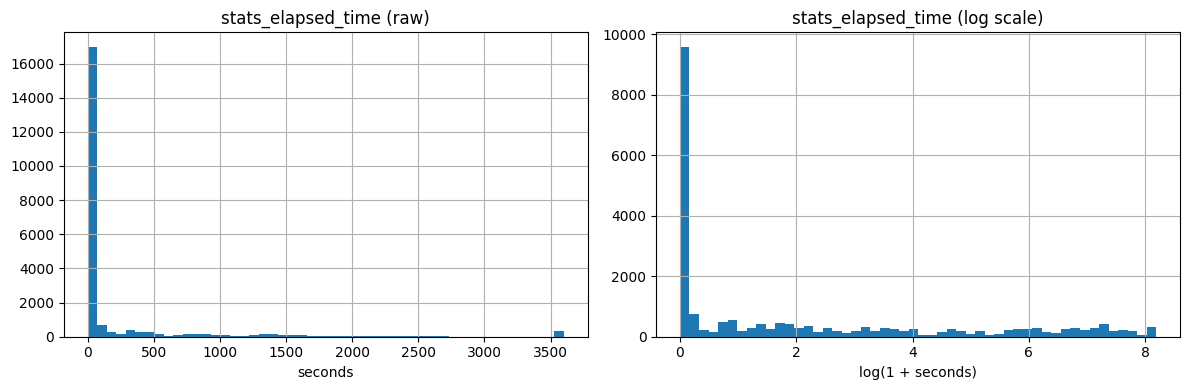

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['stats_elapsed_time'].hist(bins=50, ax=axes[0])
axes[0].set_title('stats_elapsed_time (raw)')
axes[0].set_xlabel('seconds')

np.log1p(df['stats_elapsed_time']).hist(bins=50, ax=axes[1])
axes[1].set_title('stats_elapsed_time (log scale)')
axes[1].set_xlabel('log(1 + seconds)')
plt.tight_layout()
plt.show()

cat_time
instant      3990
fast         6431
moderate     4095
slow         2380
very_slow    4906
Name: count, dtype: int64


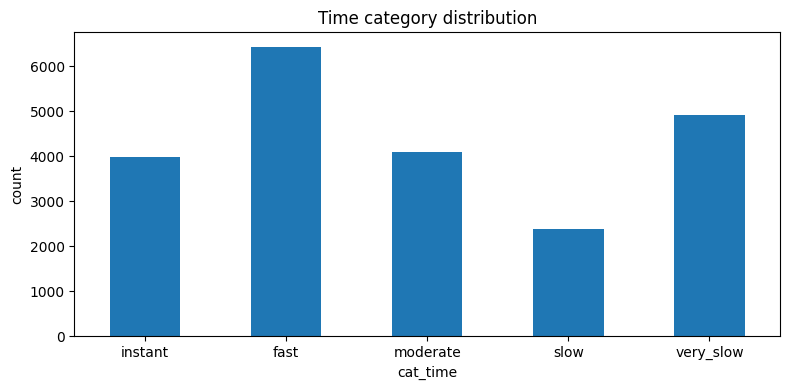

In [34]:
time_bins   = [-np.inf, 0.01, 0.5, 10, 60, np.inf]
time_labels = ['instant', 'fast', 'moderate', 'slow', 'very_slow']

df['cat_time'] = pd.cut(df['stats_elapsed_time'], bins=time_bins, labels=time_labels)

print(df['cat_time'].value_counts().sort_index())
df['cat_time'].value_counts().sort_index().plot(kind='bar', figsize=(8, 4), title='Time category distribution')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5b. Categorical variable: number of variables (`cat_nvar`)

5 categories based on `nvar`. Ranges from 1 to 500,000 — log-scale bins.

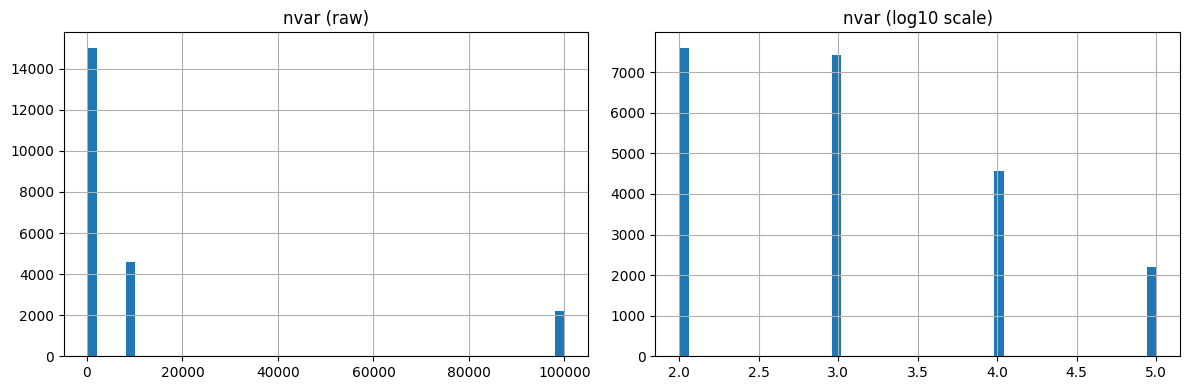

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['nvar'].hist(bins=50, ax=axes[0])
axes[0].set_title('nvar (raw)')

np.log10(df['nvar'] + 1).hist(bins=50, ax=axes[1])
axes[1].set_title('nvar (log10 scale)')
plt.tight_layout()
plt.show()

cat_nvar
tiny          7604
small         7416
medium        4577
large         2205
very_large       0
Name: count, dtype: int64


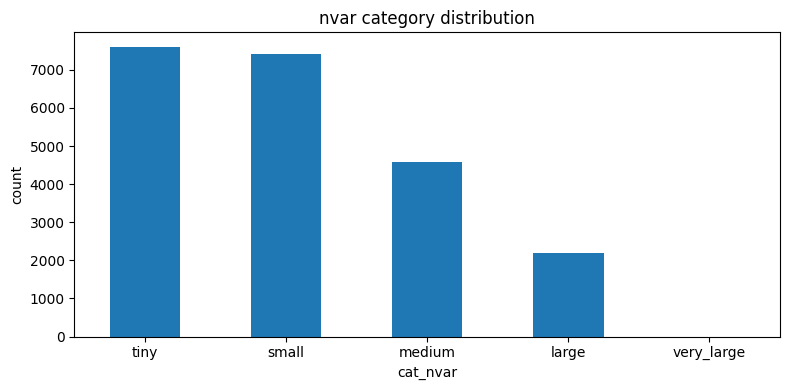

In [30]:
nvar_bins   = [0, 100, 1_000, 10_000, 100_000, 500_000]
nvar_labels = ['tiny', 'small', 'medium', 'large', 'very_large']

df['cat_nvar'] = pd.cut(df['nvar'], bins=nvar_bins, labels=nvar_labels)

print(df['cat_nvar'].value_counts().sort_index())
df['cat_nvar'].value_counts().sort_index().plot(kind='bar', figsize=(8, 4), title='nvar category distribution')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5c. Feature columns

In [31]:
df['log_nvar']        = np.log1p(df['nvar'])
df['log_timed_bytes'] = np.log1p(df['timed_bytes'])
df['log_neval_obj']   = np.log1p(df['neval_obj'])
df['log_neval_grad']  = np.log1p(df['neval_grad'])

feature_cols = [
    'log_nvar',
    'log_timed_bytes',
    'log_neval_obj',
    'log_neval_grad',
    'ncon',
    'iter',
]

print('Feature columns:', feature_cols)
df[feature_cols].describe()

Feature columns: ['log_nvar', 'log_timed_bytes', 'log_neval_obj', 'log_neval_grad', 'ncon', 'iter']


,log_nvar,log_timed_bytes,log_neval_obj,log_neval_grad,ncon,iter
count,21802.0000,21487.0000,21487.0000,21487.0000,21802.0000,21487.0000
mean,7.0565,14.6528,4.8386,4.6664,0.0000,1623.9627
std,2.2521,2.3133,1.8071,1.9434,0.0000,24364.0036
min,4.6052,9.8297,1.0986,1.0986,0.0000,1.0000
25%,4.6151,12.7100,3.5264,3.2581,0.0000,21.0000
50%,6.9088,14.5269,4.3567,4.2627,0.0000,62.0000
75%,9.2104,16.2690,5.7268,5.7104,0.0000,277.0000
max,11.5129,25.7286,14.9448,14.9447,0.0000,2229748.0000


## 6. Multivariate Multiple Regression

`neval_obj`, `neval_grad`, and `timed_bytes` are machine-independent counters — they characterise the problem itself, not the hardware. We use them to jointly predict:
- `stats_elapsed_time` — how long the solver took
- `mem` — how much memory it used

Modelling both outputs jointly captures the correlation between time and memory, giving more efficient estimates than two separate regressions.

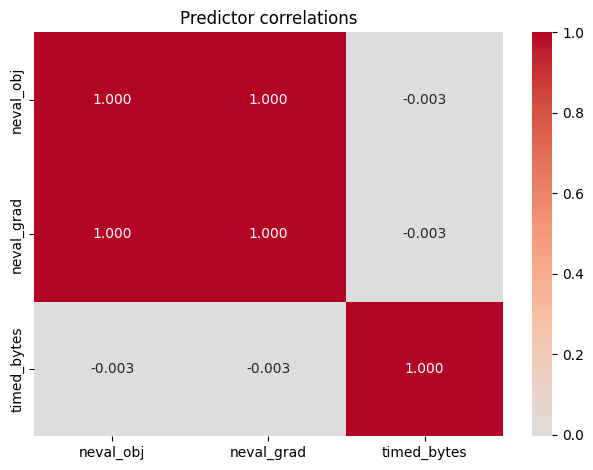

In [32]:
# Check correlations among the three predictors
pred_cols = ['neval_obj', 'neval_grad', 'timed_bytes']
corr = df[pred_cols].corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Predictor correlations')
plt.tight_layout()
plt.show()

`neval_obj` and `neval_grad` are nearly perfectly correlated (~0.998) — this makes sense, since most solvers evaluate the objective and gradient together at each iteration. Including both would make the predictor matrix singular. We keep `neval_grad` as the representative eval count since gradient evaluations are the more expensive operation.

In [33]:
multi_cols = ['neval_grad', 'timed_bytes', 'stats_elapsed_time', 'mem']
df_multi = df[multi_cols].dropna()
print(f'Multivariate dataset: {df_multi.shape[0]} rows')
df_multi.describe()

Multivariate dataset: 21487 rows


,neval_grad,timed_bytes,stats_elapsed_time,mem
count,21487.0000,21487.0000,21487.0000,21487.0000
mean,1974.1675,617133316.3450,180.9084,50.5221
std,31645.0695,8649069580.5293,468.7892,28.8544
min,2.0000,18576.0000,0.0001,1.0000
25%,25.0000,331056.0000,0.0169,26.0000
50%,70.0000,2036832.0000,0.9581,51.0000
75%,301.0000,11628360.0000,34.0077,76.0000
max,3093260.0000,149211128144.0000,3564.2733,100.0000


In [20]:
# MANOVA: joint significance test
# Do neval_grad and timed_bytes matter for time AND memory as a system?
manova = MANOVA.from_formula(
    'stats_elapsed_time + mem ~ neval_grad + timed_bytes',
    data=df_multi
)
print(manova.mv_test())

                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept        Value  Num DF   Den DF    F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.2368 2.0000 21483.0000 34619.2412 0.0000
         Pillai's trace 0.7632 2.0000 21483.0000 34619.2412 0.0000
 Hotelling-Lawley trace 3.2229 2.0000 21483.0000 34619.2412 0.0000
    Roy's greatest root 3.2229 2.0000 21483.0000 34619.2412 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
          neval_grad       Value  Num DF   Den DF   F Value Pr > F
------------------------------------------------------------------
             Wilks' lambda 0.9920 2.0000 21483.0000 86.5945 0.0000
            Pill

In [21]:
# OLS per output: coefficient-level detail
X_multi = sm.add_constant(df_multi[['neval_grad', 'timed_bytes']])

model_time = sm.OLS(df_multi['stats_elapsed_time'], X_multi).fit()
print('=== OUTPUT 1: stats_elapsed_time ===')
print(model_time.summary())

=== OUTPUT 1: stats_elapsed_time ===
                            OLS Regression Results                            
Dep. Variable:     stats_elapsed_time   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     76.77
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           6.01e-34
Time:                        13:27:04   Log-Likelihood:            -1.6256e+05
No. Observations:               21487   AIC:                         3.251e+05
Df Residuals:                   21484   BIC:                         3.252e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        

In [22]:
model_mem = sm.OLS(df_multi['mem'], X_multi).fit()
print('=== OUTPUT 2: mem ===')
print(model_mem.summary())

=== OUTPUT 2: mem ===
                            OLS Regression Results                            
Dep. Variable:                    mem   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.09
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.54e-05
Time:                        13:27:04   Log-Likelihood:            -1.0272e+05
No. Observations:               21487   AIC:                         2.055e+05
Df Residuals:                   21484   BIC:                         2.055e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          50.5803      

In [23]:
# Side-by-side coefficient comparison
def sig(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '—'))

coef_df = pd.DataFrame({
    'coef_time': model_time.params,
    'pval_time': model_time.pvalues,
    'sig_time':  model_time.pvalues.apply(sig),
    'coef_mem':  model_mem.params,
    'pval_mem':  model_mem.pvalues,
    'sig_mem':   model_mem.pvalues.apply(sig),
})
print(coef_df.round(4))

             coef_time  pval_time sig_time  coef_mem  pval_mem sig_mem
const         178.3636     0.0000      ***   50.5803    0.0000     ***
neval_grad      0.0012     0.0000      ***   -0.0000    0.0000     ***
timed_bytes     0.0000     0.7182        —   -0.0000    0.9797       —


## 7. Diagnostics

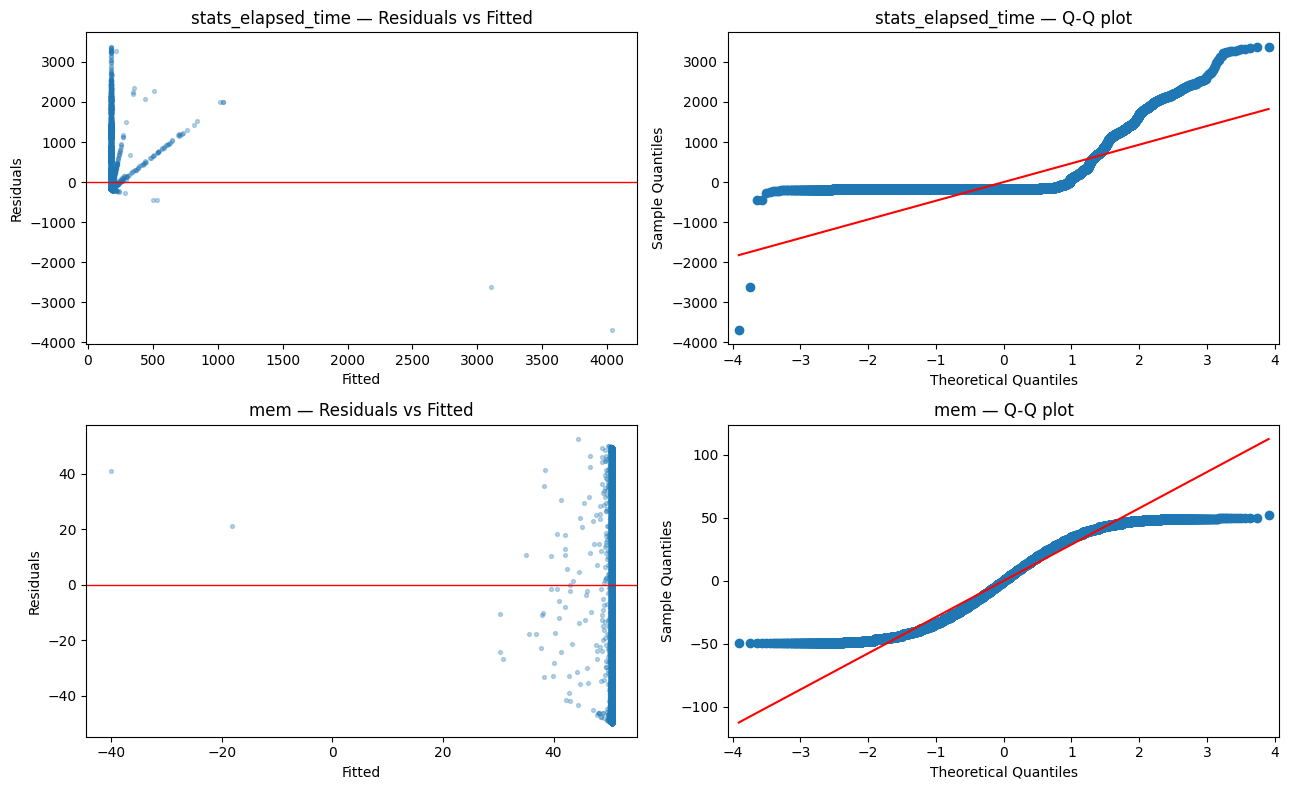

R² stats_elapsed_time : 0.0071
R² mem                : 0.0010


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, (model, title) in enumerate([
    (model_time, 'stats_elapsed_time'),
    (model_mem,  'mem')
]):
    axes[row, 0].scatter(model.fittedvalues, model.resid, alpha=0.3, s=8)
    axes[row, 0].axhline(0, color='red', lw=1)
    axes[row, 0].set_xlabel('Fitted')
    axes[row, 0].set_ylabel('Residuals')
    axes[row, 0].set_title(f'{title} — Residuals vs Fitted')

    sm.qqplot(model.resid, line='s', ax=axes[row, 1])
    axes[row, 1].set_title(f'{title} — Q-Q plot')

plt.tight_layout()
plt.show()

print(f'R² stats_elapsed_time : {model_time.rsquared:.4f}')
print(f'R² mem                : {model_mem.rsquared:.4f}')

## 8. Next Steps

- [ ] **Felix:** Send email summary of results to Tangi and Nishan  
- [ ] **Tangi:** Investigate `time_limit` and `error_*` rows skipped in the original script  
- [ ] **All:** Agree on final bin boundaries for `cat_time` and `cat_nvar`  
- [ ] **All:** Add more features from the 98 columns to `feature_cols` and re-run  
- [ ] **All:** Start column description section in the report (Section 3 above is a starting point)